In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
import numpy as np
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import log_loss, accuracy_score
from statistics import mean
import joblib

In [3]:
# Remove unnecessary columns
def clean_csv(old_filename, new_filename, remove_col_list):
    try:
        df = pd.read_csv(old_filename)
        df.drop(columns=remove_col_list, inplace=True)
        # add kelly USI feature data back
        df_usi = pd.read_csv("../data/uci_phishing_url_dataset_new.csv")
        col = df.pop("IsLegit")
        df = pd.concat([df, df_usi[["Levenshtein", "JaroWinkler", "LCS"]]], axis=1)
        # Add is Legit column back
        df.insert(len(df.columns), "IsLegit", col)
        df.to_csv(new_filename, index=False)

        print(f'file: "{old_filename}" cleaned successfully')
        return True
    except Exception as e:
        print(f'file: "{old_filename}" clean failed ({e})')
        return False

In [4]:
# Loads features and target variables
def load_data(filename, y_target_name, num_rows=-1, pos=0, isUCI_data: bool = True):
    df = pd.read_csv(filename)
    if not isUCI_data:
        df["Label"] = df["Label"].map({"Phishing": 0, "Legitimate": 1})
        df.rename(columns={"Label": "IsLegit"}, inplace=True)

    if num_rows > 0:
        df = df[pos : pos + num_rows]
    elif pos != 0:
        df = df[pos:]

    X = df.drop(columns=[y_target_name, "URL"])
    y = df[y_target_name]

    return X, y, df

In [29]:
def show_corr_matrix(df, output_filename):
    non_valid_cols = [
        df.columns[i]
        for i, item in enumerate(df.dtypes)
        if not pd.api.types.is_numeric_dtype(item)
    ]
    df.drop(columns=non_valid_cols, inplace=True)
    matrix = df.corr()
    plt.figure(figsize=(32, 16))
    sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f", linewidths=0.5)
    plt.title("UCI Phishing URL Correlation Heatmap")
    plt.savefig(output_filename)

In [6]:
def get_training_test_data(X, y):
    X_train, X_test, y_train, y_test = train_test_split(X, y, random_state=0)
    return X_train, X_test, y_train, y_test

In [7]:
def logistic_regression_model_training(X_train, X_test, y_train, y_test):
    # Speed up cos -4,4 is too slow
    C_grid = np.logspace(-3, 3, 20)
    y_train_log_loss_data = []
    y_test_log_loss_data = []
    for i, C in enumerate(C_grid):
        print(f"working on {i} with C value: {C:.4f}")
        clf = LogisticRegression(C=C, l1_ratio=0, solver="lbfgs", max_iter=500).fit(
            X_train, y_train
        )
        y_train_pred = clf.predict_proba(X_train)
        y_test_pred = clf.predict_proba(X_test)
        y_train_log_loss = log_loss(y_train, y_train_pred)
        y_test_log_loss = log_loss(y_test, y_test_pred)

        # print(f"{y_train_pred=}")
        # print(f"{y_test_pred=}")
        print(f"{y_train_log_loss=:.4f}")
        print(f"{y_test_log_loss=:.4f}")
        y_train_log_loss_data.append(y_train_log_loss)
        y_test_log_loss_data.append(y_test_log_loss)

    plt.figure()
    plt.plot(
        C_grid,
        y_train_log_loss_data,
        "o-",
        color="blue",
        label="Training Data Log-Loss",
        markersize=3,
    )
    plt.plot(
        C_grid,
        y_test_log_loss_data,
        "o-",
        color="red",
        label="Test Data Log-Loss",
        markersize=3,
    )

    plt.xlabel("C")
    plt.ylabel("Log-Loss")
    plt.title("Log-Loss of Training and Test Data Vs C")
    # plt.ylim([0, 1])
    plt.xscale("log")
    plt.legend()
    plt.savefig("../outputs/logistic_regression_log_loss_c.png")

# Add kelly's calculated feature variables into the new data

In [8]:
# df_usi = pd.read_csv("../data/uci_phishing_url_dataset_new.csv")
# pd.concat([df, df_usi[["Levenshtein", "JaroWinkler", "LCS"]]], axis=1)

In [1]:
clean_csv(
    "../data/uci_phishing_url_dataset.csv",
    "../data/uci_phishing_url_dataset_clean.csv",
    [
        "Domain",
        "TLD",
        "Title",
        "DomainTitleMatchScore",
        "IsResponsive",
        "NoOfURLRedirect",
        "NoOfSelfRedirect",
        "HasDescription",
        "NoOfPopup",
        "NoOfiFrame",
        "HasExternalFormSubmit",
        "HasHiddenFields",
        "HasPasswordField",
        "Bank",
        "Pay",
        "Crypto",
        "NoOfImage",
        "NoOfCSS",
        "URLSimilarityIndex",
        "TLDLegitimateProb",
        "URLCharProb",
    ],
)

NameError: name 'clean_csv' is not defined

remove "FILENAME" column from data


# Why hardcode this data for ur USI columns?? @kellyyyc T_T not extensible is it?

In [8]:
# X, y, df = load_data("../data/uci_phishing_url_dataset_new.csv", "IsLegit", 100000)
# CSV_PATH = "../data/uci_phishing_url_dataset_clean.csv"
CSV_PATH = "../data/url_test_data_compatible.csv"
X, y, df = load_data(CSV_PATH, "IsLegit", False)

In [9]:
df

,URL,URLLength,DomainLength,IsDomainIP,CharContinuationRate,TLDLength,NoOfSubDomain,HasObfuscation,NoOfObfuscatedChar,ObfuscationRatio,...,HasSubmitButton,HasCopyrightInfo,NoOfJS,NoOfSelfRef,NoOfEmptyRef,NoOfExternalRef,Levenshtein,JaroWinkler,LCS,IsLegit
0,https://youtube.com/watch?v=RTPI-zKWZ_M,39,11,0,1.000000,3,0,0,0,0.0,...,1,1,0,62,107,68,1.000000,1.000000,1.000000,1
1,https://www.rohmhaas.com/coatings/index.html,44,16,0,1.000000,3,1,0,0,0.0,...,1,1,2,319,54,138,1.000000,1.000000,1.000000,1
2,https://pgatour.com/players/00/19/41/,37,11,0,1.000000,3,0,0,0,0.0,...,1,1,2,8,33,376,1.000000,1.000000,1.000000,1
3,https://twitter.com/danielrbarnes,33,11,0,1.000000,3,0,0,0,0.0,...,0,0,0,0,0,0,1.000000,1.000000,1.000000,1
4,https://facebook.com/group.php?gid=34055020810,46,12,0,1.000000,3,0,0,0,0.0,...,1,1,0,21,19,79,1.000000,1.000000,1.000000,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1136,https://smalllinux.sourceforge.net/oberon/oakw...,53,26,0,0.545455,3,1,0,0,0.0,...,1,0,2,0,2,0,1.000000,1.000000,1.000000,1
1137,https://mcadams.posc.mu.edu/oswald.htm,38,19,0,0.533333,3,2,0,0,0.0,...,1,0,0,83,2,6,0.857143,0.957143,0.923077,1
1138,https://babesdb.blogspot.com/2008/04/vanessa-m...,76,20,0,0.562500,3,1,0,0,0.0,...,1,1,6,58,34,83,1.000000,1.000000,1.000000,1
1139,https://imdb.com/title/tt1380464/,33,8,0,1.000000,3,0,0,0,0.0,...,1,1,5,137,140,124,1.000000,1.000000,1.000000,1


In [ ]:
show_corr_matrix(df, "../outputs/kaggle_corr_matrix.png")

NameError: name 'show_corr_matrix' is not defined

working on 0 with C value: 0.0010


/home/khalifa/pythonPackages/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


y_train_log_loss=0.0117
y_test_log_loss=0.0129
working on 1 with C value: 0.0021


/home/khalifa/pythonPackages/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


y_train_log_loss=0.0102
y_test_log_loss=0.0114
working on 2 with C value: 0.0043


...

y_train_log_loss=0.0027
y_test_log_loss=0.0037
working on 18 with C value: 483.2930


/home/khalifa/pythonPackages/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


y_train_log_loss=0.0027
y_test_log_loss=0.0036
working on 19 with C value: 1000.0000


/home/khalifa/pythonPackages/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


y_train_log_loss=0.0023
y_test_log_loss=0.0034


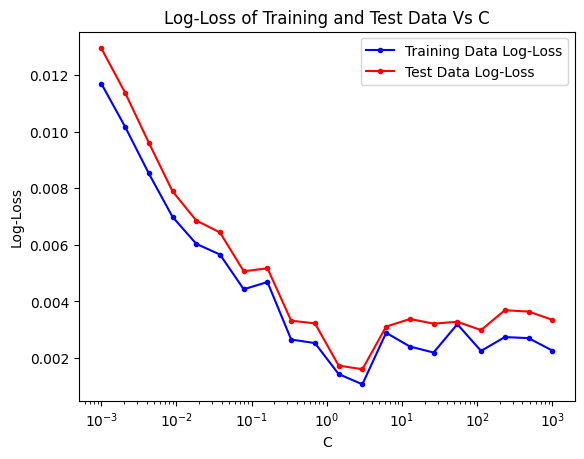

In [22]:
X_train, X_test, y_train, y_test = get_training_test_data(X, y)
logistic_regression_model_training(X_train, X_test, y_train, y_test)

In [23]:
clf = LogisticRegression(C=5, l1_ratio=0, solver="lbfgs", max_iter=500).fit(
    X_train, y_train
)
joblib.dump(
    {"features": X_train.columns.tolist(), "model": clf}, "../models/logit_model.pkl"
)

/home/khalifa/pythonPackages/lib/python3.13/site-packages/sklearn/linear_model/_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 500 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=500).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


['../models/logit_model.pkl']

In [12]:
model_dump = joblib.load("../models/logit_model.pkl")
features = model_dump["features"]
clf2 = model_dump["model"]
X_new, y_new, df_new = load_data(
    "../data/uci_phishing_url_dataset_clean.csv", "IsLegit", pos=100000
)
print(clf2.coef_)
y_new_pred = clf2.predict(X_new[features])

accuracy = accuracy_score(y_new, y_new_pred)
print(f"Accuracy: {accuracy}")

[[-3.84596294e+00  7.91622611e+00 -2.27458153e-03  1.36786511e-02
  -1.19843283e+00  1.15188629e+00 -5.65374662e-04 -2.56720077e-03
  -2.58118632e-05 -4.36152280e+00 -9.45922002e-02 -7.26848591e+00
  -2.29105341e-01 -2.70273481e-02 -4.41855803e-02 -3.51173888e-03
  -5.06485936e+00 -1.83661213e-01  6.55498182e+00  2.55928777e-02
  -9.53212875e-04  7.02925156e-02  1.24309313e-02  1.38967486e+00
   3.22385535e-01  2.95394266e+00  9.43600817e-01  3.55771795e+00
   5.30542535e-01  1.45830005e-01 -1.63694481e-01  1.43949742e-01
   5.06822511e-01  1.38944771e-02  3.42939103e-01]]
Accuracy: 0.9988070252954822


## Test against another external dataset

In [5]:
model_dump = joblib.load("../models/logit_model.pkl")
features = model_dump["features"]
clf2 = model_dump["model"]
X_new, y_true, df_new = load_data(
    "../data/url_test_data_compatible.csv",
    "IsLegit",
)
# print(clf2.coef_)
y_new_pred = clf2.predict(X_new[features])

accuracy = accuracy_score(y_true, y_new_pred)
print(f"Accuracy: {accuracy}")

Accuracy: 0.2787028921998247


# compare between y_pred and y_expected:

In [6]:
y_new_pred

array([1, 1, 1, ..., 0, 0, 1], shape=(1141,))

In [7]:
y_true

0       1
1       1
2       1
3       1
4       1
       ..
1136    1
1137    1
1138    1
1139    1
1140    1
Name: IsLegit, Length: 1141, dtype: int64